# Network Science - UDD


# Replicación del modelo nulo del paper de Lyra et al: co-bidding firm–firm network


#### *Cristian Candia-Castro Vallejos, Ph.D.*

**Universidad del Desarrollo (UDD), Chile**

- Director at the [Computational Research in Social Sciences Laboratory (CRiSS-Lab)](http://criss-lab.com) 

- Faculty, Data Science Institute, School of Engineering


**Northwestern University, United States**

- External Faculty, Northwestern Institute on Complex Systems (NICO) Kellogg School of Management.


**Capybara Spa (AI & Network Science for Preventive, Traceable School Coexistence Compliance)**

- Founder & Chief Scientific and Technological Officer (CSTO) 

---

Este notebook replica **la lógica inferencial central** de Lyra et al. (2021): partir de una red bipartita **firma–licitación**, proyectarla a una red **firma–firma** usando similitud de co-bidding, y evaluar esa similitud contra un **modelo nulo bipartito** que preserva dos restricciones importantes:

1. el **número de bids por firma y por año**;
2. el **número de firmas por licitación**.

La idea está completamente alineada con la lógica de la **Clase 4**: no interpretar una estructura observada sin compararla contra un baseline que controle explicaciones triviales.

## Qué hace este notebook

- carga el dataset público del paper o un CSV local equivalente;
- filtra las firmas “establecidas” como en el artículo;
- construye la matriz bipartita firma–licitación;
- calcula el **Jaccard centrado** entre firmas;
- genera un ensamble de randomizaciones bipartitas por año;
- estima un **p-value bootstrap** para cada par de firmas;
- construye la red firma–firma reteniendo solo asociaciones positivas y significativas;
- resume la red inferida y, opcionalmente, detecta comunidades.

## Conexión con el paper

El paper trabaja con datos de licitaciones de los 184 municipios del estado de Ceará, Brasil entre 2015 y 2019, y estima la red firma–firma a partir de patrones de co-bidding. Luego evalúa la significancia del **Jaccard centrado** usando un conjunto de **1000 randomizaciones** del bipartito original que preservan el número de bids por firma y por año, así como el número de firmas por licitación. Las aristas con $p > 0.05$ se descartan. Finalmente, la red inferida es tratada como **no dirigida y no ponderada**.

**Paper**: Characterization of the firm–firm public procurement co‑bidding network from the State of Ceará (Brazil) municipalities. https://link.springer.com/article/10.1007/s41109-021-00418-y

## Fórmula clave: Jaccard centrado

Partimos de una matriz bipartita firma–licitación. Definimos ($b_{it}=1$) si la firma (i) ofertó en la licitación (t), y ($b_{it}=0$) en caso contrario. El paper define ($p_i$) como la fracción de licitaciones en las que participa la firma (i), es decir, su tasa marginal de actividad. 

### 1. Jaccard observado

Para dos firmas (i) y (j), el Jaccard observado es

$ J_{ij} = \frac{\sum_t b_{it} b_{jt}}{\sum_t (b_{it} + b_{jt} - b_{it} b_{jt})} $

Esta razón compara:

* **numerador**: número de licitaciones en que ambas participaron;
* **denominador**: número de licitaciones en que participó al menos una de las dos.

O sea, ($J_{ij}$) mide la fracción de la **unión** de sus participaciones que corresponde a la **intersección**. Si dos firmas licitan siempre en los mismos concursos, ($J_{ij}$) es alto; si rara vez coinciden, es bajo.

### 2. Por qué el Jaccard simple no basta

El problema es que dos firmas muy activas pueden tener un Jaccard positivo simplemente porque ambas aparecen muchas veces, aunque sus decisiones sean independientes. El paper justamente quiere corregir por esa actividad marginal individual: el centered Jaccard “measures the similarity between the bidding of two firms, accounting for the occurrence probabilities of each firm”. 

### 3. Esperanza bajo independencia Bernoulli

Si modelamos las decisiones de las firmas como independientes entre licitaciones, con

$ P(b_{it}=1)=p_i, \qquad P(b_{jt}=1)=p_j $

entonces, para una licitación cualquiera:

* la probabilidad de **co-ocurrencia** es

$ P(b_{it}=1, b_{jt}=1)=p_i p_j $

* la probabilidad de que participe **al menos una** de las dos es

$ P(b_{it}=1 \ \text{o} \ b_{jt}=1)=p_i+p_j-p_i p_j $

Por tanto, el Jaccard esperado bajo ese modelo de independencia es

$ E[J_{ij}] \approx \frac{p_i p_j}{p_i + p_j - p_i p_j} $

El paper dice explícitamente que este segundo término “provides the expected number of observations when the bids from both firms are independent and identically distributed through a Bernoulli process”. La redacción del artículo es un poco imprecisa al decir “expected number of observations”, pero la idea operativa es exactamente esta corrección por independencia Bernoulli usando las probabilidades marginales ($p_i$) y ($p_j$).

### 4. Jaccard centrado

El estadístico del paper es entonces

$ J^c_{ij} = J_{ij} - E[J_{ij}] $

Interpretación rigurosa:

* si ($J^c_{ij}>0$), las firmas coinciden **más** de lo esperado dadas sus tasas marginales de participación
* si ($J^c_{ij}<0$), coinciden **menos** de lo esperado
* si ($J^c_{ij}\approx 0$), el solapamiento observado es compatible con lo esperable por actividad marginal sola

Esa es precisamente la función del centered Jaccard en el paper: distinguir asociaciones positivas y negativas “accounting for their individual level of activity”. 

### 5. Pero esto todavía no basta

Aquí está el punto más importante metodológicamente: **centrar por Bernoulli independiente no equivale al modelo nulo final del paper**.

¿Por qué? Porque la corrección analítica anterior usa un supuesto muy simple de independencia, mientras que los datos reales tienen restricciones bipartitas fuertes: número de bids por firma, número de firmas por licitación, y además variación por año. Por eso el paper no se queda solo con ($J^c_{ij}$), sino que luego evalúa su significancia construyendo una **distribución nula bootstrap** a partir de 1000 randomizaciones de la red bipartita original. Esas randomizaciones preservan el número de bids por firma y por año, y también el número de firmas que ofertan en cada licitación. Luego calculan un **p-value unilateral** para probar ($J^c_{ij}>0$), y descartan enlaces con ($p>0.05$).

### 6. Secuancia conceptual

La secuencia conceptual correcta es:

1. **Jaccard observado**: cuánto coinciden dos firmas.
2. **Corrección Bernoulli**: cuánto de esa coincidencia podría explicarse solo por sus tasas marginales de actividad.
3. **Jaccard centrado**: exceso o déficit de similitud respecto de independencia simple.
4. **Modelo nulo bipartito bootstrap**: testea si ese exceso sigue siendo inusual cuando además controlamos restricciones estructurales más realistas.


---


## Sobre la replicación

El paper usa **1000 randomizaciones** del bipartito y trabaja con una red final de miles de nodos. Eso puede ser computacionalmente costoso en un notebook local.

Por eso este notebook viene con dos modos:

- **modo clase**: más rápido, adecuado para explorar la metodología y generar resultados en minutos;
- **modo paper**: más cercano al artículo, pero más lento.

La estructura del código permite escalar el análisis si tienes tiempo de cómputo suficiente.

In [1]:
import os
import math
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
SEED = 42
rng = np.random.default_rng(SEED)

## 1. Configuración

Ajusta aquí el modo de trabajo.

- `RUN_MODE="class"` usa menos firmas y menos randomizaciones.
- `RUN_MODE="paper"` intenta acercarse más al artículo.

In [2]:
RUN_MODE = "class"  # "class" o "paper"

CONFIG = {
    "class": {
        "N_NULL": 100,
        "TOP_FIRMS": 250,
        "MIN_COOC": 1,
        "N_TRADES_CURVEBALL": 5
    },
    "paper": {
        "N_NULL": 1000,
        "TOP_FIRMS": None,
        "MIN_COOC": 1,
        "N_TRADES_CURVEBALL": 10
    }
}

cfg = CONFIG[RUN_MODE]
cfg

{'N_NULL': 100, 'TOP_FIRMS': 250, 'MIN_COOC': 1, 'N_TRADES_CURVEBALL': 5}

## 2. Carga de datos

El dataset del paper está disponible en figshare como **Ceara Public Procurement Data** y contiene, entre otros archivos, `Bipartite Bid Data.csv`. Si el notebook no puede descargarlo automáticamente en tu entorno, basta con dejar ese archivo en una carpeta `data/`.

El artículo reporta que el dataset original contiene **196,608 observaciones**, correspondientes a **45,502 firmas** y **84,835 licitaciones**, y que cada observación informa al menos una oferta de una firma a una licitación, junto con el municipio y si ganó o no el contrato.

In [4]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

FIGSHARE_URLS = [
    "https://figshare.com/s/0366318e1c881f5a2ce0"
]

LOCAL_BID_FILE = DATA_DIR / "Bipartite Bid Data.csv"

def try_download_figshare(dest=LOCAL_BID_FILE, urls=FIGSHARE_URLS, timeout=60):
    if dest.exists():
        print(f"Archivo local encontrado: {dest}")
        return dest

    try:
        import requests
    except ImportError:
        print("requests no está disponible; deja el CSV manualmente en data/.")
        return None

    for url in urls:
        try:
            print(f"Intentando descargar desde: {url}")
            r = requests.get(url, timeout=timeout)
            if r.status_code == 200 and len(r.content) > 1000:
                dest.write_bytes(r.content)
                print(f"Descargado en: {dest}")
                return dest
            else:
                print(f"Falló {url} con status={r.status_code}")
        except Exception as e:
            print(f"No se pudo descargar desde {url}: {e}")
    print("No se pudo descargar automáticamente. Copia el archivo manualmente en data/.")
    return None

bid_path = try_download_figshare()
bid_path

Intentando descargar desde: https://figshare.com/s/0366318e1c881f5a2ce0
Falló https://figshare.com/s/0366318e1c881f5a2ce0 con status=202
No se pudo descargar automáticamente. Copia el archivo manualmente en data/.


### Si la descarga automática falla

Haz esto manualmente:

1. descarga `Bipartite Bid Data.csv` desde el repositorio del paper;
2. guárdalo como `data/Bipartite Bid Data.csv`;
3. vuelve a ejecutar esta sección.

El resto del notebook asume que ese archivo existe.

In [5]:
if not LOCAL_BID_FILE.exists():
    raise FileNotFoundError(
        "No encontré 'data/Bipartite Bid Data.csv'. Descárgalo manualmente y vuelve a ejecutar."
    )

raw = pd.read_csv(LOCAL_BID_FILE)
print(raw.shape)
raw.head()

(196608, 5)


,MUNICIPALITY,TENDER,FIRMS,WINNER,YEAR
0,M_100,BID_140219,COM_25874,1,2015
1,M_100,BID_140219,COM_27968,0,2015
2,M_100,BID_140219,COM_29841,1,2015
3,M_100,BID_140219,COM_31345,1,2015
4,M_100,BID_140219,COM_40979,0,2015


## 3. Inspección y mapeo de columnas

Como el archivo puede venir con nombres de columnas distintos según la exportación, hacemos un mapeo semiautomático. El notebook intenta detectar:

- identificador de firma;
- identificador de licitación;
- año;
- municipio;
- tipo de contrato;
- indicador de ganador.

**Revisa esta sección con atención**. Si el detector se equivoca, corrige el diccionario `COLMAP` manualmente.

In [7]:
def guess_column(columns, candidates):
    # Crea un diccionario que mapea cada nombre de columna a su versión original (respetando mayúsculas).
    low = {c.lower(): c for c in columns}
    for cand in candidates:
        for k, v in low.items():
            if cand in k:
                return v
    return None

cols = list(raw.columns)

COLMAP = {
    "firm_id": guess_column(cols, ["firm", "empresa", "supplier", "bidder"]),
    "tender_id": guess_column(cols, ["tender", "licit", "procurement", "auction", "contract_id"]),
    "year": guess_column(cols, ["year", "ano", "date"]),
    "municipality": guess_column(cols, ["municip", "city", "buyer"]),
    "contract_type": guess_column(cols, ["type", "categoria", "service", "contract"]),
    "winner": guess_column(cols, ["winner", "won", "winning"])
}

COLMAP

{'firm_id': 'FIRMS',
 'tender_id': 'TENDER',
 'year': 'YEAR',
 'municipality': 'MUNICIPALITY',
 'contract_type': None,
 'winner': 'WINNER'}

In [8]:
print("Columnas disponibles:")
for c in cols:
    print("-", c)

Columnas disponibles:
- MUNICIPALITY
- TENDER
- FIRMS
- WINNER
- YEAR


### Ajuste manual opcional

Si alguna clave quedó mal detectada, corrígela aquí.

```python
COLMAP["firm_id"] = "Firm ID"
COLMAP["tender_id"] = "Tender ID"
COLMAP["year"] = "Year"
```

In [9]:
# ======== AJUSTE MANUAL (si hace falta) ========
# COLMAP["firm_id"] = "..."
# COLMAP["tender_id"] = "..."
# COLMAP["year"] = "..."
# COLMAP["municipality"] = "..."
# COLMAP["contract_type"] = "..."
# COLMAP["winner"] = "..."
# ===============================================
COLMAP

{'firm_id': 'FIRMS',
 'tender_id': 'TENDER',
 'year': 'YEAR',
 'municipality': 'MUNICIPALITY',
 'contract_type': None,
 'winner': 'WINNER'}

In [10]:
required = ["firm_id", "tender_id", "year"]
missing = [k for k in required if COLMAP[k] is None]
if missing:
    raise ValueError(f"Faltan columnas clave por mapear: {missing}")

rename_map = {
    COLMAP["firm_id"]: "firm_id",
    COLMAP["tender_id"]: "tender_id",
    COLMAP["year"]: "year",
}
if COLMAP["municipality"] is not None:
    rename_map[COLMAP["municipality"]] = "municipality"
if COLMAP["contract_type"] is not None:
    rename_map[COLMAP["contract_type"]] = "contract_type"
if COLMAP["winner"] is not None:
    rename_map[COLMAP["winner"]] = "winner"

df = raw.rename(columns=rename_map).copy()

df["firm_id"] = df["firm_id"].astype(str)
df["tender_id"] = df["tender_id"].astype(str)
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

dedup_cols = ["firm_id", "tender_id", "year"]
df = df.dropna(subset=dedup_cols).drop_duplicates(subset=dedup_cols).reset_index(drop=True)

print(df.shape)
df.head()

(196608, 5)


,municipality,tender_id,firm_id,winner,year
0,M_100,BID_140219,COM_25874,1,2015
1,M_100,BID_140219,COM_27968,0,2015
2,M_100,BID_140219,COM_29841,1,2015
3,M_100,BID_140219,COM_31345,1,2015
4,M_100,BID_140219,COM_40979,0,2015


## 4. Resumen básico del bipartito original

Antes de cualquier filtro, conviene verificar orden de magnitud.

In [11]:
summary_original = pd.Series({
    "rows_bid_observations": len(df),
    "n_firms": df["firm_id"].nunique(),
    "n_tenders": df["tender_id"].nunique(),
    "year_min": int(df["year"].min()),
    "year_max": int(df["year"].max())
})
summary_original

rows_bid_observations    196608
n_firms                   45502
n_tenders                 84835
year_min                   2015
year_max                   2019
dtype: int64

## 5. Filtro de firmas “establecidas”

El paper descarta firmas que **no ofertaron al menos una vez en cada año** del período. La motivación es quedarse con el núcleo de firmas activas y remover actividad muy esporádica. Tras este filtro, el artículo reporta un dataset de trabajo con **1906 firmas**, **72,078 bids** y **39,523 licitaciones**.

In [12]:
years = sorted(df["year"].dropna().unique().tolist())
years

[2015, 2016, 2017, 2018, 2019]

In [13]:
firm_year_counts = (
    df.groupby(["firm_id", "year"])
      .size()
      .rename("n_bids")
      .reset_index()
)

established_firms = (
    firm_year_counts.groupby("firm_id")["year"].nunique()
    .loc[lambda s: s == len(years)]
    .index
)

work = df[df["firm_id"].isin(established_firms)].copy()

paper_like_summary = pd.Series({
    "n_firms_established": work["firm_id"].nunique(),
    "rows_established": len(work),
    "n_tenders_established": work["tender_id"].nunique()
})
paper_like_summary

n_firms_established       1906
rows_established         72078
n_tenders_established    39523
dtype: int64

### Submuestreo opcional para clase

El pipeline completo del paper puede ser caro. En modo clase, por defecto nos quedamos con las firmas más activas dentro del conjunto de establecidas para que la inferencia termine en un tiempo razonable.

In [ ]:
if cfg["TOP_FIRMS"] is not None:
    ## Si queremos quedarnos solo con las firmas más activas, filtramos por número de ofertas.
    top_firms = (
        work.groupby("firm_id").size()
        .sort_values(ascending=False)
        .head(cfg["TOP_FIRMS"])
        .index
    )
    work = work[work["firm_id"].isin(top_firms)].copy()

work_summary = pd.Series({
    "n_firms_working": work["firm_id"].nunique(),
    "rows_working": len(work),
    "n_tenders_working": work["tender_id"].nunique()
})
work_summary

n_firms_working        250
rows_working         38637
n_tenders_working    20311
dtype: int64

## 6. Construcción de la matriz bipartita firma–licitación

Construimos una matriz binaria $B$ donde $B_{it}=1$ si la firma $i$ ofertó en la licitación $t$ y $0$ en otro caso.

Luego calcularemos similitud firma–firma a partir de esta matriz.

In [15]:
def build_incidence_matrix(frame, firm_col="firm_id", tender_col="tender_id"):
    firms = pd.Index(sorted(frame[firm_col].astype(str).unique()), name="firm_id")
    tenders = pd.Index(sorted(frame[tender_col].astype(str).unique()), name="tender_id")

    firm_to_idx = {f: i for i, f in enumerate(firms)}
    tender_to_idx = {t: j for j, t in enumerate(tenders)}

    rows = frame[firm_col].map(firm_to_idx).to_numpy()
    cols = frame[tender_col].map(tender_to_idx).to_numpy()
    data = np.ones(len(frame), dtype=np.int8)

    B = sp.csr_matrix((data, (rows, cols)), shape=(len(firms), len(tenders)))
    B.data[:] = 1
    B.eliminate_zeros()
    return B, firms, tenders

B, firms, tenders = build_incidence_matrix(work)
B.shape, B.nnz

((250, 20311), 38637)

## 7. Funciones para Jaccard observado, esperado y centrado

Usaremos una implementación basada en matrices dispersas. Eso hace viable calcular similitudes entre muchos pares de firmas sin iterar arista por arista.

In [16]:
def pairwise_centered_jaccard(B):
    """
    Calcula Jaccard observado, esperado y centrado para todos los pares con intersección > 0.
    Devuelve un DataFrame solo con pares candidatos (co-bids observados).
    """
    n_firms, n_tenders = B.shape
    deg = np.asarray(B.sum(axis=1)).ravel().astype(float)
    p = deg / float(n_tenders)

    inter = (B @ B.T).tocoo()
    mask = inter.row < inter.col
    rows = inter.row[mask]
    cols = inter.col[mask]
    obs_inter = inter.data[mask].astype(float)

    union = deg[rows] + deg[cols] - obs_inter
    obs_j = obs_inter / union

    exp_j = (p[rows] * p[cols]) / (p[rows] + p[cols] - p[rows] * p[cols])
    centered = obs_j - exp_j

    out = pd.DataFrame({
        "i": rows,
        "j": cols,
        "intersection": obs_inter,
        "union": union,
        "jaccard_obs": obs_j,
        "jaccard_exp_indep": exp_j,
        "jaccard_centered": centered
    })
    return out

real_pairs = pairwise_centered_jaccard(B)
real_pairs.head()

,i,j,intersection,union,jaccard_obs,jaccard_exp_indep,jaccard_centered
0,0,130,1.0,282.0,0.003546,0.003333,0.000214
1,0,125,1.0,285.0,0.003509,0.003355,0.000154
2,0,164,1.0,191.0,0.005236,0.002311,0.002925
3,0,16,1.0,412.0,0.002427,0.004012,-0.001585
4,0,71,1.0,507.0,0.001972,0.004289,-0.002317


In [17]:
real_pairs.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
i,6913.0,93.386229,60.641768,0.000000,1.000000,8.000000,91.000000,200.000000,225.000000,246.000000
j,6913.0,175.523072,55.470296,4.000000,32.000000,69.000000,188.000000,245.000000,249.000000,249.000000
intersection,6913.0,7.232171,12.781429,-126.000000,1.000000,1.000000,3.000000,29.000000,64.880000,127.000000
union,6913.0,341.572544,172.692643,130.000000,164.000000,179.000000,296.000000,702.000000,1055.520000,1763.000000
jaccard_obs,6913.0,0.022489,0.035087,-0.233766,0.001125,0.002392,0.009901,0.087649,0.169164,0.436464
jaccard_exp_indep,6913.0,0.003771,0.001461,0.001973,0.002069,0.002249,0.003434,0.006423,0.009200,0.021795
jaccard_centered,6913.0,0.018718,0.035088,-0.238830,-0.005702,-0.002572,0.006339,0.084026,0.165452,0.433487


## 8. Modelo nulo del paper: randomización bipartita por año

Esta es la parte central del notebook.

El artículo genera **1000 randomizaciones del bipartito original** preservando:

- el número de bids por firma **y por año**;
- el número de firmas participantes en cada licitación.

La forma más limpia de implementar esta restricción es randomizar **dentro de cada año** la matriz binaria firma–licitación preservando las sumas de filas y columnas. Aquí usamos el algoritmo **Curveball**, que randomiza una matriz binaria preservando sus marginales.

In [18]:
def sparse_to_row_sets(B):
    B = B.tocsr()
    row_sets = []
    for i in range(B.shape[0]):
        row_sets.append(set(B.indices[B.indptr[i]:B.indptr[i+1]].tolist()))
    return row_sets

def row_sets_to_sparse(row_sets, n_cols):
    rows, cols = [], []
    for i, s in enumerate(row_sets):
        if len(s) == 0:
            continue
        rows.extend([i] * len(s))
        cols.extend(sorted(s))
    data = np.ones(len(rows), dtype=np.int8)
    return sp.csr_matrix((data, (rows, cols)), shape=(len(row_sets), n_cols))

def curveball_trade(row_sets, a, b, rng):
    A = row_sets[a]
    B = row_sets[b]
    only_a = list(A - B)
    only_b = list(B - A)
    if len(only_a) == 0 or len(only_b) == 0:
        return
    pool = only_a + only_b
    rng.shuffle(pool)
    new_a_only = set(pool[:len(only_a)])
    new_b_only = set(pool[len(only_a):])
    common = A & B
    row_sets[a] = common | new_a_only
    row_sets[b] = common | new_b_only

def curveball_randomize_binary_matrix(B, n_trades=1000, seed=42):
    rng = random.Random(seed)
    row_sets = sparse_to_row_sets(B)
    n_rows = len(row_sets)
    for _ in range(n_trades):
        a, b = rng.sample(range(n_rows), 2)
        curveball_trade(row_sets, a, b, rng)
    return row_sets_to_sparse(row_sets, B.shape[1])

def build_year_blocks(frame):
    blocks = {}
    for y, sub in frame.groupby("year"):
        By, fy, ty = build_incidence_matrix(sub, "firm_id", "tender_id")
        blocks[int(y)] = {"B": By, "firms": fy, "tenders": ty, "frame": sub.copy()}
    return blocks

year_blocks = build_year_blocks(work)
{y: year_blocks[y]["B"].shape for y in year_blocks}

{2015: (250, 3693),
 2016: (250, 3148),
 2017: (250, 4968),
 2018: (250, 4451),
 2019: (250, 4051)}

### Por qué randomizar por año

Si randomizáramos toda la matriz junta, una firma podría mover actividad de un año a otro. Eso violaría el control del paper. Al randomizar cada bloque anual por separado, preservamos las restricciones marginales **dentro de cada año**.

In [23]:
def randomized_work_from_year_blocks(year_blocks, n_trades_curveball=5, seed=42):
    rng_local = np.random.default_rng(seed)
    pieces = []
    for y, block in year_blocks.items():
        By = block["B"]
        n_trades = max(n_trades_curveball * By.nnz, 100)
        Byr = curveball_randomize_binary_matrix(By, n_trades=n_trades, seed=int(rng_local.integers(0, 1e9)))

        r_idx, c_idx = Byr.nonzero()
        part = pd.DataFrame({
            "firm_id": block["firms"].take(r_idx).astype(str),
            "tender_id": block["tenders"].take(c_idx).astype(str),
            "year": y
        })
        pieces.append(part)
    return pd.concat(pieces, ignore_index=True)

rand_work_example = randomized_work_from_year_blocks(
    year_blocks, 
    n_trades_curveball=cfg["N_TRADES_CURVEBALL"], 
    seed=SEED
)

rand_work_example.head(), rand_work_example.shape

(     firm_id   tender_id  year
 0  COM_23068   BID_10057  2015
 1  COM_23068   BID_10249  2015
 2  COM_23068   BID_10507  2015
 3  COM_23068  BID_124166  2015
 4  COM_23068  BID_124442  2015,
 (38637, 3))

## 9. Chequeo del nulo: ¿preserva lo que debe preservar?

Antes de usar el nulo, conviene auditarlo. El paper es muy explícito: el randomizado debe preservar el número de bids por firma y por año, y el número de firmas por licitación.

In [24]:
def validate_null_constraints(real_frame, rand_frame):
    real_firm_year = real_frame.groupby(["firm_id", "year"]).size().sort_index()
    rand_firm_year = rand_frame.groupby(["firm_id", "year"]).size().sort_index()

    real_tender_year = real_frame.groupby(["tender_id", "year"]).size().sort_index()
    rand_tender_year = rand_frame.groupby(["tender_id", "year"]).size().sort_index()

    firm_cmp = pd.concat(
        [real_firm_year.rename("real"), rand_firm_year.rename("rand")],
        axis=1
    ).fillna(0)
    firm_cmp["diff"] = firm_cmp["rand"] - firm_cmp["real"]

    tender_cmp = pd.concat(
        [real_tender_year.rename("real"), rand_tender_year.rename("rand")],
        axis=1
    ).fillna(0)
    tender_cmp["diff"] = tender_cmp["rand"] - tender_cmp["real"]

    checks = {
        "firm_year_preserved": (firm_cmp["diff"] == 0).all(),
        "tender_year_preserved": (tender_cmp["diff"] == 0).all(),
        "same_n_rows": len(real_frame) == len(rand_frame),
        "n_firm_year_changed": int((firm_cmp["diff"] != 0).sum()),
        "n_tender_year_changed": int((tender_cmp["diff"] != 0).sum()),
        "max_abs_firm_year_diff": int(firm_cmp["diff"].abs().max()),
        "max_abs_tender_year_diff": int(tender_cmp["diff"].abs().max()),
    }
    return checks, firm_cmp, tender_cmp

validate_null_constraints(work[["firm_id","tender_id","year"]], rand_work_example)

({'firm_year_preserved': True,
  'tender_year_preserved': True,
  'same_n_rows': True,
  'n_firm_year_changed': 0,
  'n_tender_year_changed': 0,
  'max_abs_firm_year_diff': 0,
  'max_abs_tender_year_diff': 0},
                 real  rand  diff
 firm_id   year                  
 COM_23068 2015    24    24     0
           2016     9     9     0
           2017    42    42     0
           2018    21    21     0
           2019    15    15     0
 ...              ...   ...   ...
 COM_48181 2015     8     8     0
           2016    12    12     0
           2017    33    33     0
           2018    19    19     0
           2019    23    23     0
 
 [1250 rows x 3 columns],
                   real  rand  diff
 tender_id   year                  
 BID_1000    2015     3     3     0
 BID_100000b 2017     5     5     0
 BID_100001  2019     1     1     0
 BID_100004  2019     1     1     0
 BID_100005  2019     2     2     0
 ...                ...   ...   ...
 BID_99861   2016     1     1   

## 10. Distribución nula de $J^c_{ij}$ y p-values bootstrap

En el paper, para cada par de firmas se construye una distribución nula de $J^c_{ij}$ a partir de un ensamble de randomizaciones. Luego se calcula un **p-value de cola superior**:

$ p_{ij} = P_{null}(\hat{J}^c_{ij} \ge J^c_{ij}) $

y se descartan pares con $p > 0.05$.

### Nota computacional

Hacer esto para **todos** los pares y con **1000** nulls puede ser caro. Por eso aquí usamos una estrategia razonable para clase:

- trabajamos solo sobre pares con al menos un co-bid observado;
- y acumulamos la distribución nula solo para esos pares candidatos.

In [25]:
candidate_pairs = real_pairs[real_pairs["intersection"] >= cfg["MIN_COOC"]].copy()
candidate_pairs["pair_key"] = list(zip(candidate_pairs["i"], candidate_pairs["j"]))
candidate_pairs = candidate_pairs.reset_index(drop=True)

pair_to_obs = dict(zip(candidate_pairs["pair_key"], candidate_pairs["jaccard_centered"]))
len(candidate_pairs)

6901

In [26]:
def pairwise_centered_jaccard_lookup(B, only_pairs=None):
    out = pairwise_centered_jaccard(B)
    if only_pairs is not None:
        only_pairs = set(only_pairs)
        pair_keys = list(zip(out["i"], out["j"]))
        mask = [pk in only_pairs for pk in pair_keys]
        out = out.loc[mask].copy()
        pair_keys = list(zip(out["i"], out["j"]))
    else:
        pair_keys = list(zip(out["i"], out["j"]))
    return dict(zip(pair_keys, out["jaccard_centered"]))

def simulate_null_pair_scores(year_blocks, candidate_pairs, n_null=100, seed=42, n_trades_curveball=5):
    only_pairs = set(candidate_pairs["pair_key"])
    null_scores = {pk: [] for pk in only_pairs}
    real_firm_to_idx = {f: i for i, f in enumerate(firms)}
    real_tender_to_idx = {t: j for j, t in enumerate(tenders)}

    for r in range(n_null):
        if (r + 1) % 10 == 0:
            print(f"Null {r+1}/{n_null}")
        rand_work = randomized_work_from_year_blocks(
            year_blocks, 
            n_trades_curveball=n_trades_curveball, 
            seed=seed + r
        )
        rr = rand_work["firm_id"].map(real_firm_to_idx)
        cc = rand_work["tender_id"].map(real_tender_to_idx)
        keep = rr.notna() & cc.notna()
        Br = sp.csr_matrix(
            (np.ones(keep.sum(), dtype=np.int8), (rr[keep].astype(int), cc[keep].astype(int))),
            shape=(len(firms), len(tenders))
        )
        Br.data[:] = 1
        Br.eliminate_zeros()

        scores = pairwise_centered_jaccard_lookup(Br, only_pairs=only_pairs)
        for pk in only_pairs:
            null_scores[pk].append(scores.get(pk, np.nan))
    return null_scores

t0 = time.time()
null_scores = simulate_null_pair_scores(
    year_blocks,
    candidate_pairs,
    n_null=cfg["N_NULL"],
    seed=SEED,
    n_trades_curveball=cfg["N_TRADES_CURVEBALL"]
)
print("Tiempo total (s):", round(time.time() - t0, 2))

Null 10/100
Null 20/100
Null 30/100
Null 40/100
Null 50/100
Null 60/100
Null 70/100
Null 80/100
Null 90/100
Null 100/100
Tiempo total (s): 677.19


## 11. Estimación de p-values y construcción de la red firma–firma

Usaremos un p-value empírico de cola superior con corrección +1:

$ \hat{p}_{ij} = \frac{1 + \sum_{r=1}^{R} \mathbb{1}(\hat{J}^{c,(r)}_{ij} \ge J^c_{ij})}{R + 1} $

Luego conservamos pares con:

- $J^c_{ij} > 0$;
- $p_{ij} \le 0.05$.

In [27]:
def empirical_upper_tail_pvalue(obs, null_vals):
    arr = np.asarray([x for x in null_vals if pd.notna(x)], dtype=float)
    if len(arr) == 0:
        return np.nan
    return (1 + np.sum(arr >= obs)) / (len(arr) + 1)

results = candidate_pairs.copy()
results["p_value_upper"] = [
    empirical_upper_tail_pvalue(pair_to_obs[pk], null_scores[pk]) 
    for pk in results["pair_key"]
]
results["significant"] = (results["jaccard_centered"] > 0) & (results["p_value_upper"] <= 0.05)
results.head()

,i,j,intersection,union,jaccard_obs,jaccard_exp_indep,jaccard_centered,pair_key,p_value_upper,significant
0,0,130,1.0,282.0,0.003546,0.003333,0.000214,"(0, 130)",1.0,False
1,0,125,1.0,285.0,0.003509,0.003355,0.000154,"(0, 125)",1.0,False
2,0,164,1.0,191.0,0.005236,0.002311,0.002925,"(0, 164)",1.0,False
3,0,16,1.0,412.0,0.002427,0.004012,-0.001585,"(0, 16)",1.0,False
4,0,71,1.0,507.0,0.001972,0.004289,-0.002317,"(0, 71)",1.0,False


In [28]:
results["significant"].mean(), results["significant"].sum()

(0.3584987682944501, 2474)

In [29]:
sig_edges = results.loc[results["significant"], ["i", "j", "jaccard_centered", "p_value_upper"]].copy()

G_ff = nx.Graph()
for idx, f in enumerate(firms):
    G_ff.add_node(idx, firm_id=f)

for _, row in sig_edges.iterrows():
    G_ff.add_edge(
        int(row["i"]), int(row["j"]),
        jc=float(row["jaccard_centered"]),
        p=float(row["p_value_upper"])
    )

basic_sig_summary = pd.Series({
    "n_nodes": G_ff.number_of_nodes(),
    "n_edges": G_ff.number_of_edges(),
    "density": nx.density(G_ff),
    "n_components": nx.number_connected_components(G_ff),
    "avg_degree": np.mean([d for _, d in G_ff.degree()]) if G_ff.number_of_nodes() > 0 else np.nan,
    "avg_clustering": nx.average_clustering(G_ff) if G_ff.number_of_nodes() > 0 else np.nan
})
basic_sig_summary

n_nodes            250.000000
n_edges           2474.000000
density              0.079486
n_components        16.000000
avg_degree          19.792000
avg_clustering       0.580925
dtype: float64

## 12. Diagnóstico: ¿se parece razonablemente al paper?

El artículo reporta, para la red final inferida:

- **1529 nodos**;
- **12,892 aristas**;
- **grado medio 16.86**;
- **clustering 0.52**;
- **56 componentes**.

No esperes coincidencia exacta si:

- el mapeo de columnas no es idéntico;
- usaste submuestreo `TOP_FIRMS`;
- corriste menos de 1000 nulls;
- o la limpieza del CSV difiere ligeramente.

La comparación útil aquí es metodológica: ¿la red final emerge tras un filtro de similitud **y** significancia contra un nulo bipartito bien controlado?

In [30]:
paper_numbers = pd.Series({
    "paper_nodes": 1529,
    "paper_edges": 12892,
    "paper_avg_degree": 16.86,
    "paper_avg_clustering": 0.52,
    "paper_components": 56
})
pd.concat([basic_sig_summary, paper_numbers])

n_nodes                   250.000000
n_edges                  2474.000000
density                     0.079486
n_components               16.000000
avg_degree                 19.792000
avg_clustering              0.580925
paper_nodes              1529.000000
paper_edges             12892.000000
paper_avg_degree           16.860000
paper_avg_clustering        0.520000
paper_components           56.000000
dtype: float64

## 13. Visualizaciones básicas

Primero veremos las distribuciones de:

- grado;
- clustering local por grado;
- componentes conectadas.

,n_nodos,n_aristas,grado_medio,grado_max,clustering_medio,transitividad
0,250,2474,19.792,73,0.580925,0.585749


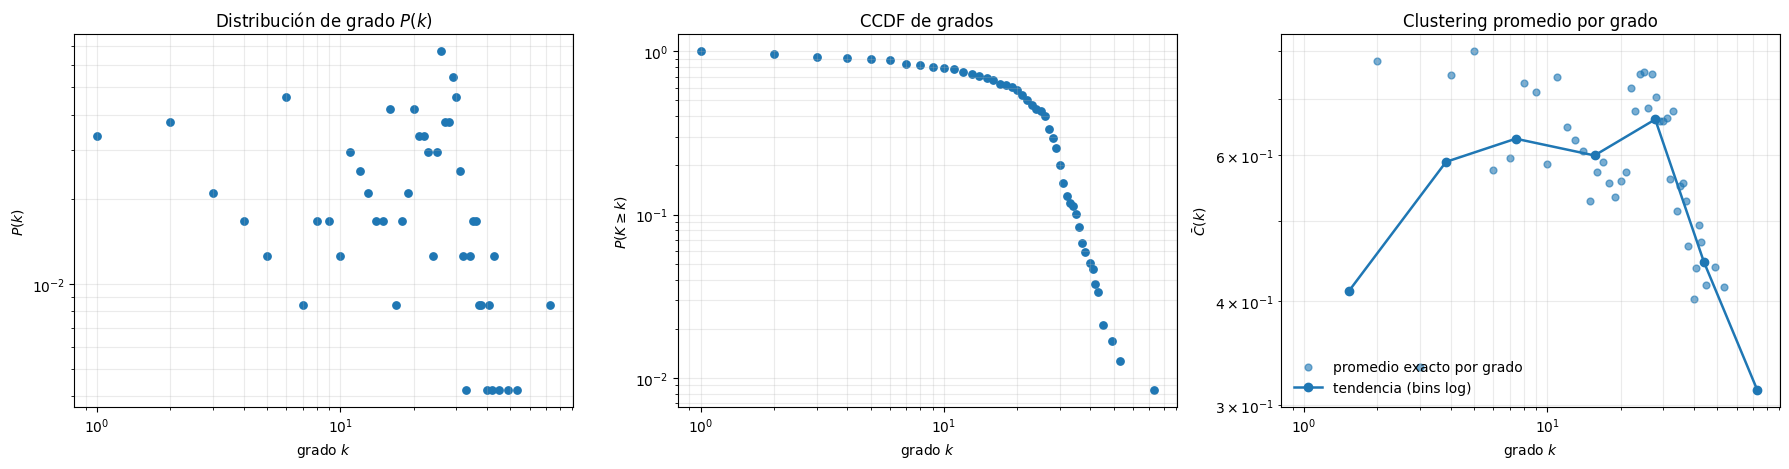

In [37]:
if G_ff.number_of_edges() > 0:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from collections import Counter

    # =========================
    # 1) Grados
    # =========================
    degrees = np.array([d for _, d in G_ff.degree()])
    degrees_pos = degrees[degrees > 0]

    # PMF: P(k)
    degree_counts = Counter(degrees_pos)
    k_vals = np.array(sorted(degree_counts.keys()))
    pk_vals = np.array([degree_counts[k] / len(degrees_pos) for k in k_vals])

    # CCDF: P(K >= k)
    sorted_deg = np.sort(degrees_pos)
    ccdf_x = np.unique(sorted_deg)
    ccdf_y = np.array([(sorted_deg >= k).mean() for k in ccdf_x])

    # =========================
    # 2) Clustering por grado
    # =========================
    cc = nx.clustering(G_ff)
    cc_df = pd.DataFrame({
        "degree": [G_ff.degree(n) for n in G_ff.nodes()],
        "clustering": [cc[n] for n in G_ff.nodes()]
    })

    # promedio exacto por grado
    by_deg = (
        cc_df[cc_df["degree"] > 0]
        .groupby("degree", as_index=False)["clustering"]
        .mean()
        .sort_values("degree")
    )

    # =========================
    # 3) Binning logarítmico para clustering por grado
    # =========================
    # útil cuando hay pocos nodos en grados altos
    unique_deg = np.sort(cc_df.loc[cc_df["degree"] > 0, "degree"].unique())

    if len(unique_deg) >= 4:
        n_bins = min(8, len(unique_deg))
        bins = np.unique(
            np.logspace(
                np.log10(unique_deg.min()),
                np.log10(unique_deg.max()),
                n_bins
            ).astype(int)
        )

        # asegurar bordes válidos
        bins = bins[bins > 0]
        if len(bins) >= 2:
            cc_df_pos = cc_df[cc_df["degree"] > 0].copy()
            cc_df_pos["deg_bin"] = pd.cut(
                cc_df_pos["degree"],
                bins=np.append(bins, bins[-1] + 1),
                right=False,
                include_lowest=True
            )

            by_bin = (
                cc_df_pos
                .dropna(subset=["deg_bin"])
                .groupby("deg_bin", observed=False)
                .agg(
                    degree_mean=("degree", "mean"),
                    clustering_mean=("clustering", "mean"),
                    n_nodes=("degree", "size")
                )
                .reset_index(drop=True)
            )
        else:
            by_bin = None
    else:
        by_bin = None

    # =========================
    # 4) Figura principal
    # =========================
    fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))

    # (a) PMF en log-log
    ax[0].scatter(k_vals, pk_vals, s=28)
    ax[0].set_xscale("log")
    ax[0].set_yscale("log")
    ax[0].set_title("Distribución de grado $P(k)$")
    ax[0].set_xlabel("grado $k$")
    ax[0].set_ylabel("$P(k)$")
    ax[0].grid(True, which="both", alpha=0.25)

    # (b) CCDF en log-log
    ax[1].scatter(ccdf_x, ccdf_y, s=28)
    ax[1].set_xscale("log")
    ax[1].set_yscale("log")
    ax[1].set_title("CCDF de grados")
    ax[1].set_xlabel("grado $k$")
    ax[1].set_ylabel("$P(K \\geq k)$")
    ax[1].grid(True, which="both", alpha=0.25)

    # (c) Clustering promedio por grado
    ax[2].scatter(
        by_deg["degree"],
        by_deg["clustering"],
        s=24,
        alpha=0.6,
        label="promedio exacto por grado"
    )

    if by_bin is not None and len(by_bin) > 0:
        ax[2].plot(
            by_bin["degree_mean"],
            by_bin["clustering_mean"],
            marker="o",
            linewidth=1.8,
            label="tendencia (bins log)"
        )

    ax[2].set_xscale("log")
    ax[2].set_yscale("log")
    ax[2].set_title("Clustering promedio por grado")
    ax[2].set_xlabel("grado $k$")
    ax[2].set_ylabel("$\\bar{C}(k)$")
    ax[2].grid(True, which="both", alpha=0.25)
    ax[2].legend(frameon=False)

    plt.tight_layout()

    # =========================
    # 5) Resumen numérico opcional
    # =========================
    summary_df = pd.DataFrame({
        "n_nodos": [G_ff.number_of_nodes()],
        "n_aristas": [G_ff.number_of_edges()],
        "grado_medio": [degrees.mean()],
        "grado_max": [degrees.max()],
        "clustering_medio": [nx.average_clustering(G_ff)],
        "transitividad": [nx.transitivity(G_ff)]
    })

    display(summary_df)

else:
    print("La red resultante no tiene aristas; revisa parámetros o columnas.")

## 14. Comunidades (opcional)

El paper usa **Louvain** y reporta **22 comunidades** con modularidad alta. Aquí usamos el algoritmo disponible en NetworkX (`louvain_communities`) si la versión instalada lo soporta.

In [32]:
community_partition = None
modularity_value = np.nan

try:
    if G_ff.number_of_edges() > 0:
        communities = nx.community.louvain_communities(G_ff, seed=SEED)
        community_partition = {}
        for cid, comm in enumerate(communities):
            for n in comm:
                community_partition[n] = cid
        modularity_value = nx.community.modularity(G_ff, communities)
        print(f"Número de comunidades: {len(communities)}")
        print(f"Modularidad: {modularity_value:.4f}")
except Exception as e:
    print("No se pudo correr Louvain con esta versión de NetworkX:", e)

Número de comunidades: 21
Modularidad: 0.6431


## 15. Indicadores opcionales del paper

Si tu CSV trae columnas como `municipality`, `contract_type` o `winner`, puedes extender la replicación hacia la parte sustantiva del artículo:

- **diversidad regional y de tipo de contrato** con índice de Simpson;
- **single bidder** por comunidad;
- **número medio de bidders por tender**, normalizado por tamaño de comunidad.

Esos indicadores aparecen en la segunda mitad del paper y se usan para perfilar comunidades con riesgo potencial.

In [33]:
def simpson_index(series):
    p = series.value_counts(normalize=True)
    return (p ** 2).sum()

if community_partition is not None:
    node_to_firm = {n: G_ff.nodes[n]["firm_id"] for n in G_ff.nodes()}
    firm_to_comm = {f: community_partition[n] for n, f in node_to_firm.items()}

    work_comm = work[work["firm_id"].isin(firm_to_comm)].copy()
    work_comm["community"] = work_comm["firm_id"].map(firm_to_comm)

    optional_tables = []

    if "municipality" in work_comm.columns:
        reg_div = work_comm.groupby("community")["municipality"].apply(simpson_index).rename("simpson_region")
        optional_tables.append(reg_div)
    if "contract_type" in work_comm.columns:
        type_div = work_comm.groupby("community")["contract_type"].apply(simpson_index).rename("simpson_contract_type")
        optional_tables.append(type_div)
    if "winner" in work_comm.columns:
        bidders_per_tender = work_comm.groupby(["year", "tender_id"]).size().rename("n_bidders").reset_index()
        tmp = work_comm.merge(bidders_per_tender, on=["year", "tender_id"], how="left")
        single_bid = (
            tmp.assign(single_bid=(tmp["n_bidders"] == 1).astype(int))
               .groupby("community")["single_bid"]
               .mean()
               .rename("share_single_bid")
        )
        optional_tables.append(single_bid)

    if optional_tables:
        profile = pd.concat(optional_tables, axis=1).sort_index()
        display(profile.head(10))
    else:
        print("No encontré columnas sustantivas extra para perfilar comunidades.")
else:
    print("No hay partición comunitaria disponible todavía.")

,simpson_region,share_single_bid
community,,
0,0.028891,0.228757
1,0.010858,0.816981
2,0.007739,0.854571
3,0.026039,1.000000
4,0.028502,0.925926
5,0.015266,0.238373
6,0.081744,1.000000
7,0.032845,1.000000
8,0.220937,1.000000


## 16. Lectura metodológica: qué controla y qué no controla este nulo

### Qué sí controla
- actividad anual de cada firma;
- tamaño de cada licitación en términos de número de participantes;
- tasas marginales de participación;
- parte importante de la coincidencia espuria por “estar en muchos tenderes”.

### Qué no controla
- geografía;
- tipo de contrato;
- coordinación estratégica real;
- historia temporal más fina dentro del año;
- atributos no observados.

Ese es exactamente el punto de Clase 4: **un modelo nulo no prueba un mecanismo**, pero sí evita interpretar como “señal” algo que puede emerger solo por restricciones básicas del sistema.

## 17. Checklist de interpretación

Al terminar, intenta responder estas preguntas:

1. ¿Cuántas aristas sobreviven al filtro de significancia?
2. ¿La red final es mucho más estructurada que lo que cabría esperar por tasas marginales y tamaños de tender?
3. ¿Aparecen comunidades bien definidas?
4. ¿Hay grupos con baja diversidad regional o de tipo de contrato?
5. ¿Hay comunidades con baja tasa de single bidders y licitaciones con participantes muy alineados con el tamaño de la comunidad?

La conclusión correcta no es “detectamos colusión”, sino algo más cuidadoso:

> **identificamos grupos de firmas con patrones de co-bidding improbables bajo un nulo bipartito bien controlado, que merecen análisis sustantivo adicional.**

## 18. Referencias mínimas

- Lyra, M. S., Curado, A., Damásio, B., Bação, F., & Pinheiro, F. L. (2021). *Characterization of the firm–firm public procurement co‑bidding network from the State of Ceará (Brazil) municipalities*. Applied Network Science, 6, 77.
- Chung, N. C., et al. (2019). *Jaccard/Tanimoto similarity test and estimation methods for biological presence-absence data*.
- Gotelli, N. J. (2000). *Null model analysis of species co-occurrence patterns*.

### Nota final
El paper deja explícito que estos indicadores son **exploratorios** y que la falta de etiquetas de corrupción impide hacer una atribución causal directa. El objetivo del pipeline es **reducir el espacio de búsqueda** para auditoría, no reemplazar investigación sustantiva.